# Sentiment140 Transformer Model: BERT Fine-Tuning

This notebook implements the transformer-based sentiment model for the Sentiment140 pipeline under the unified project structure.

It is designed to:
- load the fixed Sentiment140 splits from `artifacts/sentiment140/splits/`
- fine-tune a **binary** BERT sentiment classifier on the Sentiment140 dataset
- save reusable experiment artifacts under the Sentiment140 subfolder
- export publication-ready figures for later thesis writing
- support later construction of a **happiness index** through sentiment probabilities and aggregate sentiment scores

## Why this model matters for the thesis
Compared with the TF-IDF + Logistic Regression baseline and the BiLSTM neural baseline, BERT can capture richer contextual semantics and longer-range dependencies in social media text. This makes it a stronger model for examining whether transformer-based sentiment estimation can provide a more reliable basis for happiness index construction.

## Prerequisite: Install the transformer stack
Make sure the required libraries for Hugging Face Transformers are available in the current environment, including `transformers`, `datasets`, `accelerate`, and `torch`.

The notebook will verify the required packages before training starts.

## 0. Verify required packages

This section checks whether the core Python packages for the BERT experiment are available in the current environment.

In [1]:
import importlib
import subprocess
import sys


def install_if_missing(package_name, import_name=None):
    module_name = import_name or package_name
    try:
        importlib.import_module(module_name)
        print(f"✅ {package_name} already installed")
    except ImportError:
        print(f"⬇️ Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])


required_packages = [
    ("numpy", "numpy"),
    ("pandas", "pandas"),
    ("matplotlib", "matplotlib"),
    ("seaborn", "seaborn"),
    ("scikit-learn", "sklearn"),
    ("datasets", "datasets"),
    ("transformers", "transformers"),
    ("accelerate", "accelerate"),
    ("torch", "torch"),
]

for package_name, import_name in required_packages:
    install_if_missing(package_name, import_name)

print(f"Python executable: {sys.executable}")

✅ numpy already installed
✅ pandas already installed
✅ matplotlib already installed
✅ seaborn already installed
✅ scikit-learn already installed
✅ datasets already installed
✅ transformers already installed
✅ accelerate already installed
✅ torch already installed
Python executable: d:\Anaconda\envs\happiness-nlp\python.exe


## 1. Setup and unified paths

This section imports the required libraries, defines a consistent artifact structure, and sets the core experiment configuration for the Sentiment140 BERT pipeline.

In [2]:
import os
os.environ["USE_TF"] = "0"
os.environ["USE_FLAX"] = "0"

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    EarlyStoppingCallback,
    set_seed,
)
from transformers import logging

logging.disable_progress_bar()

BASE_DIR = Path("..")
ARTIFACT_ROOT = BASE_DIR / "artifacts"
DATASET_NAME = "sentiment140"
DATASET_ARTIFACT_DIR = ARTIFACT_ROOT / DATASET_NAME

SPLIT_DIR = DATASET_ARTIFACT_DIR / "splits"
PRED_DIR = DATASET_ARTIFACT_DIR / "predictions"
MODEL_DIR = DATASET_ARTIFACT_DIR / "models"
CONFIG_DIR = DATASET_ARTIFACT_DIR / "config"
FIG_DIR = DATASET_ARTIFACT_DIR / "figures"
RESULT_DIR = DATASET_ARTIFACT_DIR / "results"
TRAINING_OUTPUT_DIR = DATASET_ARTIFACT_DIR / "bert_training_outputs"

for folder in [
    ARTIFACT_ROOT,
    DATASET_ARTIFACT_DIR,
    SPLIT_DIR,
    PRED_DIR,
    MODEL_DIR,
    CONFIG_DIR,
    FIG_DIR,
    RESULT_DIR,
    TRAINING_OUTPUT_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = SPLIT_DIR / "train_60.csv"
VAL_PATH = SPLIT_DIR / "val_10.csv"
TEST_PATH = SPLIT_DIR / "test_30.csv"

MODEL_NAME = "bert-base-uncased"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 2
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
RANDOM_STATE = 42

NEG_TH = 0.40
POS_TH = 0.60

TRAIN_SAMPLE_SIZE = None
VAL_SAMPLE_SIZE = None
TEST_SAMPLE_SIZE = None

set_seed(RANDOM_STATE)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
sns.set_theme(style="whitegrid")

print("Using device:", device)
print("Train path:", TRAIN_PATH.resolve())
print("Val path:", VAL_PATH.resolve())
print("Test path:", TEST_PATH.resolve())

Using device: cuda
Train path: E:\桌面\Graduation_Thesis\Code\artifacts\sentiment140\splits\train_60.csv
Val path: E:\桌面\Graduation_Thesis\Code\artifacts\sentiment140\splits\val_10.csv
Test path: E:\桌面\Graduation_Thesis\Code\artifacts\sentiment140\splits\test_30.csv


## 2. Load dataset splits

This section loads the pre-saved Sentiment140 splits and prepares them for the transformer-based experiment.

In [3]:
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nColumns in train_df:", list(train_df.columns))
train_df.head(3)

Train shape: (960000, 3)
Val shape: (160000, 3)
Test shape: (480000, 3)

Columns in train_df: ['text', 'text_clean', 'label']


,text,text_clean,label
0,thx@MJIC: &quot;&gt;100Listeners!thk you all ...,thx user 100listeners!thk you all hi user user...,1
1,Ergh miserable weather,ergh miserable weather,0
2,@lizmoney Apple's in-ears are slightly comfy f...,user apple's in ears are slightly comfy for me...,1


## 3. Validate the split schema

This section checks whether the split files follow the expected schema and keeps the export logic aligned with the raw and cleaned text fields used in earlier notebooks.

In [4]:
required_cols = ["label"]
missing_cols = [c for c in required_cols if c not in train_df.columns]
if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

for df_name, df in [("train_df", train_df), ("val_df", val_df), ("test_df", test_df)]:
    if "text" not in df.columns and "text_clean" not in df.columns:
        raise KeyError(f"{df_name} must contain at least one text column: 'text' or 'text_clean'.")

def ensure_text_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if "text" not in df.columns:
        df["text"] = df["text_clean"]
    if "text_clean" not in df.columns:
        df["text_clean"] = df["text"]
    return df[["text", "text_clean", "label"]]

train_df = ensure_text_columns(train_df)
val_df = ensure_text_columns(val_df)
test_df = ensure_text_columns(test_df)

print("Standardized train columns:", list(train_df.columns))
train_df.head(3)

Standardized train columns: ['text', 'text_clean', 'label']


,text,text_clean,label
0,thx@MJIC: &quot;&gt;100Listeners!thk you all ...,thx user 100listeners!thk you all hi user user...,1
1,Ergh miserable weather,ergh miserable weather,0
2,@lizmoney Apple's in-ears are slightly comfy f...,user apple's in ears are slightly comfy for me...,1


## 4. Optionally sample the splits for faster fine-tuning

This section keeps the notebook practical to run while preserving the same split schema and export structure.

In [5]:
if TRAIN_SAMPLE_SIZE and len(train_df) > TRAIN_SAMPLE_SIZE:
    train_df = train_df.sample(TRAIN_SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)

if VAL_SAMPLE_SIZE and len(val_df) > VAL_SAMPLE_SIZE:
    val_df = val_df.sample(VAL_SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)

if TEST_SAMPLE_SIZE and len(test_df) > TEST_SAMPLE_SIZE:
    test_df = test_df.sample(TEST_SAMPLE_SIZE, random_state=RANDOM_STATE).reset_index(drop=True)

print("After optional sampling:")
print("Train:", len(train_df))
print("Val:", len(val_df))
print("Test:", len(test_df))

After optional sampling:
Train: 960000
Val: 160000
Test: 480000


## 5. Build Hugging Face datasets

This section converts the tabular data into Hugging Face datasets while preserving both raw and cleaned text for later analysis and artifact export.

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)

def build_hf_dataset(df: pd.DataFrame) -> Dataset:
    data = {
        "text": df["text"].astype(str).tolist(),
        "text_clean": df["text_clean"].astype(str).tolist(),
        "label": df["label"].astype(int).tolist(),
    }
    return Dataset.from_dict(data)

train_ds_raw = build_hf_dataset(train_df)
val_ds_raw = build_hf_dataset(val_df)
test_ds_raw = build_hf_dataset(test_df)

train_ds_raw

Dataset({
    features: ['text', 'text_clean', 'label'],
    num_rows: 960000
})

## 6. Tokenize the text inputs

This section tokenizes the text field for BERT while keeping padding dynamic through the data collator.

In [7]:
def tokenize_batch(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,
        max_length=MAX_LEN,
    )

train_ds = train_ds_raw.map(tokenize_batch, batched=True)
val_ds = val_ds_raw.map(tokenize_batch, batched=True)
test_ds = test_ds_raw.map(tokenize_batch, batched=True)

train_ds = train_ds.rename_column("label", "labels")
val_ds = val_ds.rename_column("label", "labels")
test_ds = test_ds.rename_column("label", "labels")

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

train_ds

Map:   0%|          | 0/960000 [00:00<?, ? examples/s]

Map:   0%|          | 0/160000 [00:00<?, ? examples/s]

Map:   0%|          | 0/480000 [00:00<?, ? examples/s]

Dataset({
    features: ['text', 'text_clean', 'labels', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 960000
})

## 7. Load the pretrained BERT classifier

This section initializes a binary BERT classifier for fine-tuning on the Sentiment140 sentiment labels.

In [8]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
)

print(model.__class__.__name__)

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BertForSequenceClassification


## 8. Define evaluation metrics

This section computes the main binary classification metrics used to compare the BERT model with the earlier TF-IDF and BiLSTM baselines.

In [9]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="binary", zero_division=0
    )
    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

## 9. Configure training arguments

This section defines the training setup, including checkpointing and early stopping based on validation performance.

In [10]:
training_args = TrainingArguments(
    output_dir=str(TRAINING_OUTPUT_DIR),
    num_train_epochs=EPOCHS,
    per_device_train_batch_size=BATCH_SIZE,
    per_device_eval_batch_size=BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=50,
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,
    report_to="none",
    seed=RANDOM_STATE,
)

## 10. Build the Trainer

This section combines the model, datasets, tokenizer, and callbacks into a Hugging Face Trainer workflow.

In [11]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)

## 11. Fine-tune BERT

This section trains the BERT classifier and keeps the best checkpoint according to validation performance.

In [12]:
train_result = trainer.train()
train_result

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,0.359738,0.312350,0.868331,0.870792,0.865012,0.867893
2,0.222174,0.325815,0.873344,0.876777,0.868788,0.872764


There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=120000, training_loss=0.29763436204592386, metrics={'train_runtime': 15030.7051, 'train_samples_per_second': 127.739, 'train_steps_per_second': 7.984, 'total_flos': 4.259370030807168e+16, 'train_loss': 0.29763436204592386, 'epoch': 2.0})

## 12. Export training history and learning curves

This section saves the logged training history and creates a simple loss curve for later reporting in the thesis.

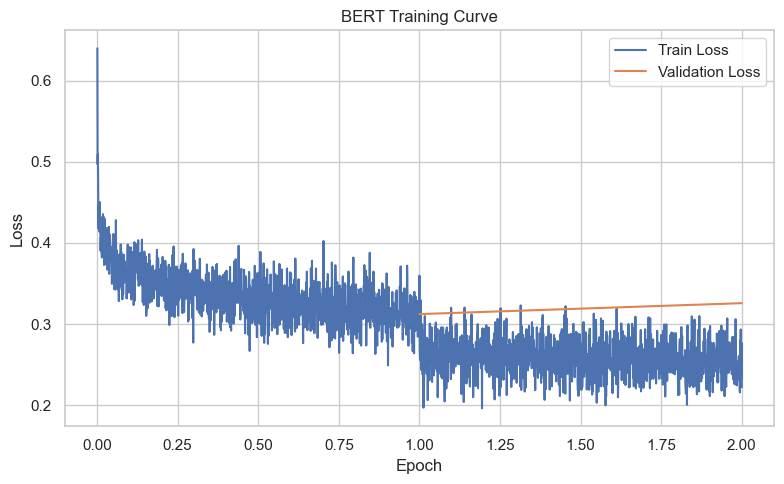

Saved training curve: E:\桌面\Graduation_Thesis\Code\artifacts\sentiment140\figures\bert_training_curve.png
Saved training history: E:\桌面\Graduation_Thesis\Code\artifacts\sentiment140\config\bert_training_history.csv


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
2398,0.232613,4.117078,1.683333e-08,1.998333,119900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2399,0.276917,3.223940,8.500000e-09,1.999167,119950,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2400,0.222174,3.793045,1.666667e-10,2.000000,120000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2401,NaN,NaN,NaN,2.000000,120000,0.325815,0.873344,0.876777,0.868788,0.872764,313.2172,510.828,31.927,NaN,NaN,NaN,NaN,NaN
2402,NaN,NaN,NaN,2.000000,120000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15030.7051,127.739,7.984,4.259370e+16,0.297634


In [13]:
log_history = pd.DataFrame(trainer.state.log_history)
history_path = CONFIG_DIR / "bert_training_history.csv"
log_history.to_csv(history_path, index=False, encoding="utf-8")

plot_df = log_history.copy()
if "epoch" in plot_df.columns and ("loss" in plot_df.columns or "eval_loss" in plot_df.columns):
    plt.figure(figsize=(8, 5))
    if "loss" in plot_df.columns:
        train_curve = plot_df.dropna(subset=["loss", "epoch"])[["epoch", "loss"]]
        if not train_curve.empty:
            plt.plot(train_curve["epoch"], train_curve["loss"], label="Train Loss")
    if "eval_loss" in plot_df.columns:
        eval_curve = plot_df.dropna(subset=["eval_loss", "epoch"])[["epoch", "eval_loss"]]
        if not eval_curve.empty:
            plt.plot(eval_curve["epoch"], eval_curve["eval_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("BERT Training Curve")
    plt.legend()
    plt.tight_layout()
    curve_path = FIG_DIR / "bert_training_curve.png"
    plt.savefig(curve_path, dpi=300, bbox_inches="tight")
    plt.show()
    print("Saved training curve:", curve_path.resolve())
else:
    print("Training history did not contain plottable loss values.")

print("Saved training history:", history_path.resolve())
log_history.tail()

## 13. Evaluate on the test set

This section evaluates the best BERT checkpoint on the test split and prepares probability-based outputs for downstream analysis.

Classification report:
              precision    recall  f1-score   support

           0     0.8707    0.8788    0.8747    240000
           1     0.8777    0.8694    0.8736    240000

    accuracy                         0.8741    480000
   macro avg     0.8742    0.8741    0.8741    480000
weighted avg     0.8742    0.8741    0.8741    480000


Confusion matrix:
[[210921  29079]
 [ 31332 208668]]


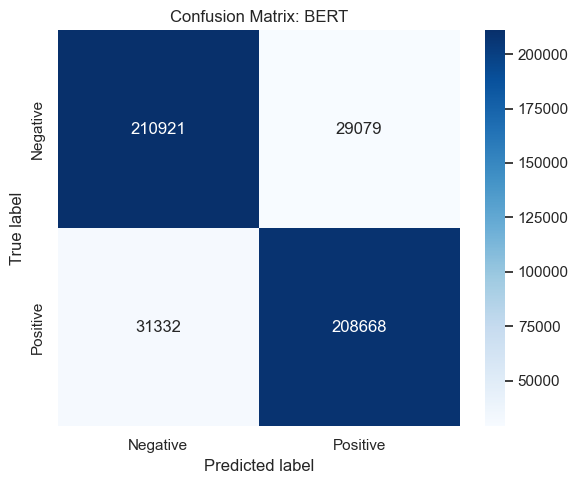

Saved confusion matrix figure: E:\桌面\Graduation_Thesis\Code\artifacts\sentiment140\figures\bert_confusion_matrix.png


In [14]:
test_output = trainer.predict(test_ds)

logits = test_output.predictions
y_true = np.array(test_ds["labels"])

probs_tensor = torch.softmax(torch.tensor(logits), dim=1)
proba_pos = probs_tensor[:, 1].numpy()

pred_binary = np.argmax(logits, axis=1)

print("Classification report:")
print(classification_report(y_true, pred_binary, digits=4))

cm = confusion_matrix(y_true, pred_binary)
print("\nConfusion matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=True,
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix: BERT")
plt.tight_layout()

cm_path = FIG_DIR / "bert_confusion_matrix.png"
plt.savefig(cm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrix figure:", cm_path.resolve())

## 14. Apply a neutral-zone post-processing strategy

This section converts binary positive probabilities into a three-way interpretation by introducing a neutral range between two thresholds.

In [15]:
def proba_to_3class(probs, neg_th=0.40, pos_th=0.60):
    labels = []
    for p in probs:
        if p <= neg_th:
            labels.append("NEGATIVE")
        elif p >= pos_th:
            labels.append("POSITIVE")
        else:
            labels.append("NEUTRAL")
    return labels

pred_3class = proba_to_3class(proba_pos, neg_th=NEG_TH, pos_th=POS_TH)

neutral_rate = np.mean(np.array(pred_3class) == "NEUTRAL")
print(f"Neutral rate on test set: {neutral_rate:.4f}")

Neutral rate on test set: 0.0349


## 15. Export prediction artifacts

This section saves both binary and neutral-aware prediction files using the same artifact pattern adopted in the previous notebooks.

In [16]:
pred_binary_df = pd.DataFrame({
    "text": test_df["text"].astype(str).tolist(),
    "text_clean": test_df["text_clean"].astype(str).tolist(),
    "y_true": y_true.astype(int),
    "proba_pos": proba_pos.astype(float),
    "pred_binary": pred_binary.astype(int),
})

# Add reusable score columns for later happiness-index aggregation.
pred_binary_df["score_label_binary"] = pred_binary_df["pred_binary"].map({0: -1, 1: 1})
pred_binary_df["score_prob_continuous"] = 2 * pred_binary_df["proba_pos"] - 1

pred_neutral_df = pred_binary_df.copy()
pred_neutral_df["pred_3class"] = pred_3class
pred_neutral_df["score_label_3class"] = pred_neutral_df["pred_3class"].map({
    "NEGATIVE": -1,
    "NEUTRAL": 0,
    "POSITIVE": 1,
})

binary_path = PRED_DIR / "pred_test_bert_binary.csv"
neutral_path = PRED_DIR / f"pred_test_bert_neutral_{NEG_TH:.2f}_{POS_TH:.2f}.csv"

pred_binary_df.to_csv(binary_path, index=False, encoding="utf-8")
pred_neutral_df.to_csv(neutral_path, index=False, encoding="utf-8")

print("Saved binary predictions:", binary_path.resolve())
print("Saved neutral-aware predictions:", neutral_path.resolve())


Saved binary predictions: E:\桌面\Graduation_Thesis\Code\artifacts\sentiment140\predictions\pred_test_bert_binary.csv
Saved neutral-aware predictions: E:\桌面\Graduation_Thesis\Code\artifacts\sentiment140\predictions\pred_test_bert_neutral_0.40_0.60.csv


## 16. Save the fine-tuned model and tokenizer

This section exports the final BERT model artifacts so the classifier can be reused for inference and later comparison.

In [17]:
BERT_SAVE_DIR = MODEL_DIR / "bert_model"
BERT_SAVE_DIR.mkdir(parents=True, exist_ok=True)

trainer.model.save_pretrained(BERT_SAVE_DIR)
tokenizer.save_pretrained(BERT_SAVE_DIR)

print("Saved BERT model to:", BERT_SAVE_DIR.resolve())

Saved BERT model to: E:\桌面\Graduation_Thesis\Code\artifacts\sentiment140\models\bert_model


## 17. Construct static happiness indices

This section converts BERT sentiment predictions into static happiness-index summaries for the Sentiment140 test split.

Two versions are exported:
- **Binary HI**, which follows the original Sentiment140 binary sentiment setting.
- **Neutral-aware HI**, which applies the same post-hoc neutral zone used in the other Sentiment140 notebooks.

Both versions are reported on the raw `[-1, 1]` scale and on the presentation-friendly `[0, 100]` scale.


In [18]:
def safe_mean(series):
    s = pd.to_numeric(series, errors="coerce")
    return float(s.mean()) if s.notna().any() else np.nan


def ratio(series, value):
    return float((series == value).mean())


binary_hi = {
    "dataset": "sentiment140",
    "model": "bert_base_uncased",
    "index_variant": "binary_hi",
    "sample_size": int(len(pred_binary_df)),
    "negative_ratio": ratio(pred_binary_df["pred_binary"], 0),
    "neutral_ratio": np.nan,
    "positive_ratio": ratio(pred_binary_df["pred_binary"], 1),
    "mean_proba_pos": safe_mean(pred_binary_df["proba_pos"]),
    "hi_label_raw": safe_mean(pred_binary_df["score_label_binary"]),
    "hi_label_100": float(50 * (safe_mean(pred_binary_df["score_label_binary"]) + 1)),
    "hi_prob_raw": safe_mean(pred_binary_df["score_prob_continuous"]),
    "hi_prob_100": float(50 * (safe_mean(pred_binary_df["score_prob_continuous"]) + 1)),
    "neg_th": np.nan,
    "pos_th": np.nan,
    "base_model": MODEL_NAME,
    "max_len": int(MAX_LEN),
    "batch_size": int(BATCH_SIZE),
    "epochs": int(EPOCHS),
}

neutral_hi = {
    "dataset": "sentiment140",
    "model": "bert_base_uncased",
    "index_variant": "neutral_hi",
    "sample_size": int(len(pred_neutral_df)),
    "negative_ratio": ratio(pred_neutral_df["pred_3class"], "NEGATIVE"),
    "neutral_ratio": ratio(pred_neutral_df["pred_3class"], "NEUTRAL"),
    "positive_ratio": ratio(pred_neutral_df["pred_3class"], "POSITIVE"),
    "mean_proba_pos": safe_mean(pred_neutral_df["proba_pos"]),
    "hi_label_raw": safe_mean(pred_neutral_df["score_label_3class"]),
    "hi_label_100": float(50 * (safe_mean(pred_neutral_df["score_label_3class"]) + 1)),
    "hi_prob_raw": safe_mean(pred_neutral_df["score_prob_continuous"]),
    "hi_prob_100": float(50 * (safe_mean(pred_neutral_df["score_prob_continuous"]) + 1)),
    "neg_th": float(NEG_TH),
    "pos_th": float(POS_TH),
    "base_model": MODEL_NAME,
    "max_len": int(MAX_LEN),
    "batch_size": int(BATCH_SIZE),
    "epochs": int(EPOCHS),
}

happiness_summary_df = pd.DataFrame([binary_hi, neutral_hi])

summary_csv_path = RESULT_DIR / "bert_happiness_index_summary.csv"
binary_json_path = RESULT_DIR / "bert_happiness_index_binary.json"
neutral_json_path = RESULT_DIR / "bert_happiness_index_neutral.json"

happiness_summary_df.to_csv(summary_csv_path, index=False, encoding="utf-8")

with open(binary_json_path, "w", encoding="utf-8") as f:
    json.dump(binary_hi, f, ensure_ascii=False, indent=2)

with open(neutral_json_path, "w", encoding="utf-8") as f:
    json.dump(neutral_hi, f, ensure_ascii=False, indent=2)

print("Saved BERT happiness summary CSV:", summary_csv_path.resolve())
print("Saved BERT binary HI JSON:", binary_json_path.resolve())
print("Saved BERT neutral-aware HI JSON:", neutral_json_path.resolve())

display(happiness_summary_df)


Saved BERT happiness summary CSV: E:\桌面\Graduation_Thesis\Code\artifacts\sentiment140\results\bert_happiness_index_summary.csv
Saved BERT binary HI JSON: E:\桌面\Graduation_Thesis\Code\artifacts\sentiment140\results\bert_happiness_index_binary.json
Saved BERT neutral-aware HI JSON: E:\桌面\Graduation_Thesis\Code\artifacts\sentiment140\results\bert_happiness_index_neutral.json


,dataset,model,index_variant,sample_size,negative_ratio,neutral_ratio,positive_ratio,mean_proba_pos,hi_label_raw,hi_label_100,hi_prob_raw,hi_prob_100,neg_th,pos_th,base_model,max_len,batch_size,epochs
0,sentiment140,bert_base_uncased,binary_hi,480000,0.504694,NaN,0.495306,0.497064,-0.009388,49.530625,-0.005871,49.706437,NaN,NaN,bert-base-uncased,128,16,2
1,sentiment140,bert_base_uncased,neutral_hi,480000,0.486815,0.034912,0.478273,0.497064,-0.008542,49.572917,-0.005871,49.706437,0.4,0.6,bert-base-uncased,128,16,2


## 18. Optional quick demo

This section runs a few example sentences through the fine-tuned classifier to illustrate probability outputs and the neutral-zone interpretation.

In [28]:
demo_texts = [
    "I am so happy today!",
    "This product is terrible and disappointing.",
    "It does not matter.",
]

demo_device = trainer.model.device

demo_enc = tokenizer(
    demo_texts,
    truncation=True,
    padding=True,
    max_length=MAX_LEN,
    return_tensors="pt",
)

demo_enc = {k: v.to(demo_device) for k, v in demo_enc.items()}

with torch.no_grad():
    demo_logits = trainer.model(**demo_enc).logits
    demo_probs = torch.softmax(demo_logits, dim=1)[:, 1].cpu().numpy()
    demo_binary = np.argmax(demo_logits.cpu().numpy(), axis=1)
    demo_3class = proba_to_3class(demo_probs, NEG_TH, POS_TH)

list(zip(demo_texts, demo_probs, demo_binary, demo_3class))

[('I am so happy today!', np.float32(0.99830353), np.int64(1), 'POSITIVE'),
 ('This product is terrible and disappointing.',
  np.float32(0.0021565312),
  np.int64(0),
  'NEGATIVE'),
 ('It does not matter.', np.float32(0.54125136), np.int64(1), 'NEUTRAL')]